In [3]:
import sys
import numpy as np
import matplotlib.pyplot as plt


sys.path.append('../')
from src_experiment.dataset import get_new_data

In [4]:
train, test = get_new_data("mnist_minimal")

Fetching MNIST Minimal (downsampled to 7x7)...


100%|██████████| 9.91M/9.91M [00:05<00:00, 1.91MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 141kB/s]
100%|██████████| 1.65M/1.65M [00:03<00:00, 450kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.5MB/s]


Images shape: torch.Size([32, 49])
Labels shape: torch.Size([32])


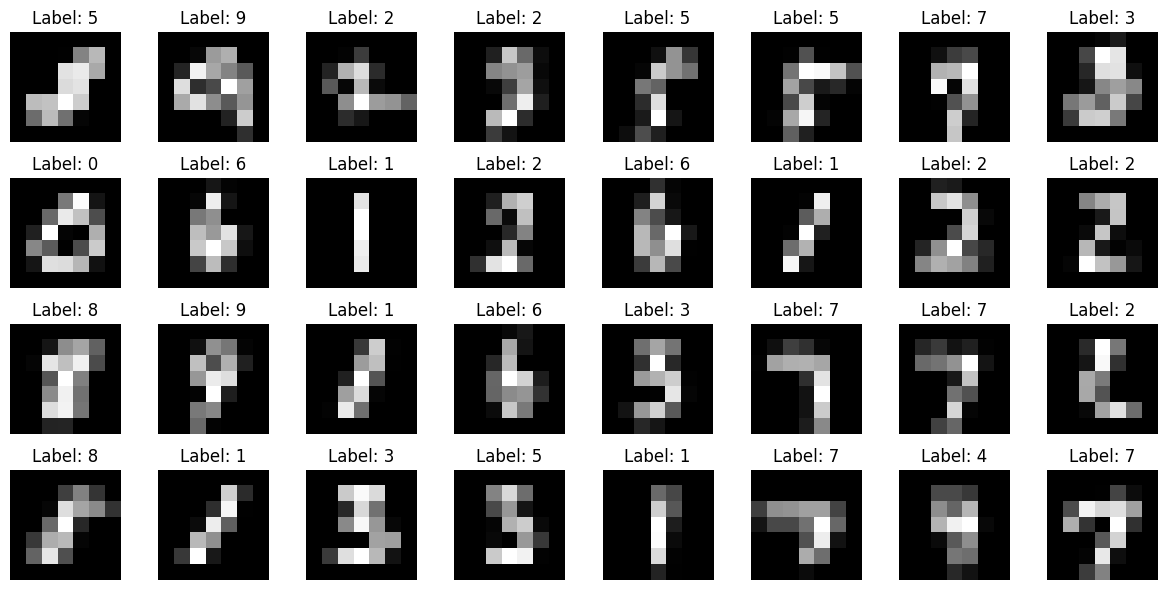

In [18]:
import matplotlib.pyplot as plt

# Get a batch of data
sample = next(iter(train))
images = sample[0]
labels = sample[1]

print(f"Images shape: {images.shape}")  # Shape of the input data
print(f"Labels shape: {labels.shape}")  # Shape of the labels   

# Function that displays the entire batch of 32 images
def display_batch(images, labels):
    # Create a 4x8 grid of subplots
    fig, axes = plt.subplots(nrows=4, ncols=8, figsize=(12, 6))
    
    # Flatten the axes array so we can iterate over it with a single loop
    axes = axes.flatten()
    
    for i in range(len(images)):
        ax = axes[i]
        
        # Squeeze removes single-dimensional entries from the shape (e.g., channels)
        image = images[i].reshape(7,7)
        
        # .item() gets the standard Python number from the tensor
        label = labels[i].item() 
        
        ax.imshow(image, cmap='gray')  # Display the image
        ax.set_title(f'Label: {label}')  # Display the label as title
        ax.axis('off')  # Hide axes
        
    # Adjust layout so titles don't overlap
    plt.tight_layout()
    plt.show()

# Call the function
display_batch(images, labels)

In [19]:
def verify_dataset_hypercube(dataloader):
    all_in_hypercube = True
    global_min = float('inf')
    global_max = float('-inf')

    for batch_idx, (images, _) in enumerate(dataloader):
        # Update global min and max
        batch_min = images.min().item()
        batch_max = images.max().item()
        
        if batch_min < global_min: global_min = batch_min
        if batch_max > global_max: global_max = batch_max

        # Check if this specific batch violates the boundaries
        if not ((images >= 0.0) & (images <= 1.0)).all():
            print(f"Violation found in batch {batch_idx}! Min: {batch_min}, Max: {batch_max}")
            all_in_hypercube = False
            
    print(f"--- Final Results ---")
    print(f"Global Minimum: {global_min}")
    print(f"Global Maximum: {global_max}")
    print(f"Entire dataset in unit hypercube: {all_in_hypercube}")

# Run the check on your train dataset
verify_dataset_hypercube(train)

--- Final Results ---
Global Minimum: 0.0
Global Maximum: 1.0
Entire dataset in unit hypercube: True
